In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(r'D:\EDA\eda_practice_dataset.csv')

In [3]:
df.head()

,customer_id,age,gender,annual_income,purchase_amount,purchase_date,city,product_category,rating,loyalty_member
0,1860.0,54,NaN,64653 USD,4839.323231247608,18/09/2018,NaN,home,3.9,No
1,6390.0,NaN,male,110481,286.77382935259624,15/10/2022,mumbai,electronics,4.6,1
2,6226.0,23,female,72802,1653.0764573090369,2023-01-23,Mumbai,NaN,3.2,0
3,6191.0,38,M,"27,549",2036.1591064046295,2021-07-03,NaN,Electronics,4.2/5,Yes
4,4772.0,49,Male,98933 USD,1244.2499090052866,2019-12-29,Mumbai,Electronics,3.4,N


In [4]:
df.columns

Index(['customer_id', 'age', 'gender', 'annual_income', 'purchase_amount',
       'purchase_date', 'city', 'product_category', 'rating',
       'loyalty_member'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       4850 non-null   float64
 1   age               4732 non-null   str    
 2   gender            4155 non-null   str    
 3   annual_income     4850 non-null   str    
 4   purchase_amount   4850 non-null   str    
 5   purchase_date     4850 non-null   str    
 6   city              4249 non-null   str    
 7   product_category  4032 non-null   str    
 8   rating            4796 non-null   str    
 9   loyalty_member    4174 non-null   str    
dtypes: float64(1), str(9)
memory usage: 390.8 KB


In [6]:
for column in df:
    print(column)
    print()
    print(df[column].unique())
    print("------------------------------------------")

customer_id

[1860. 6390. 6226. ... 3934. 1203. 5487.]
------------------------------------------
age

<StringArray>
[     '54',       nan,      '23',      '38',      '49',      '52',      '32',
      '22',      '63',      '67',      '65',      '42',      '57',      '46',
      '24',      '30',      '55',      '35',      '19',      '25',      '28',
      '50',      '44',      '37',      '60',      '48',      '27',      '20',
      '62',      '33',      '66',      '69',      '68',      '47', 'unknown',
      '39',      '31',      '41',      '53',      '36',      '21',      '40',
      '51',      '29',      '59',      '61',      '58',      '18',      '64',
      '34',      '45',      '43',      '26',      '56',       '5',     '120',
      '-3']
Length: 57, dtype: str
------------------------------------------
gender

<StringArray>
[nan, 'male', 'female', 'M', 'Male', 'Female', 'F']
Length: 7, dtype: str
------------------------------------------
annual_income

<StringArray>
[ '64653 USD'

In [7]:
df['customer_id'].nunique()

3265

In [8]:
df.drop_duplicates(subset = ['customer_id'], keep='first', inplace = True)

In [9]:
invalid_values = ['unknown', '-3']
df['age'] = df['age'].replace(invalid_values, np.nan)

In [10]:
df['age'] = df['age'].astype(float)
df['age'] = df['age'].fillna(df['age'].median())

In [11]:
df['age'] = df['age'].astype(int)

In [12]:
df['gender'] = df['gender'].replace(['M', 'male'], 'Male')
df['gender'] = df['gender'].replace(['F', 'female'], 'Female')

In [13]:
df['annual_income'] = df['annual_income'].astype(str).str.replace(r'[^0-9]', '', regex = True)
df['annual_income'] = pd.to_numeric(df['annual_income'], errors = 'coerce')

In [14]:
df['annual_income'] = df['annual_income'].fillna(df['annual_income'].median())

In [15]:
df['annual_income'] = df['annual_income'].astype(int)

In [16]:
df['purchase_amount'] = df['purchase_amount'].astype(float)
df['purchase_amount'] = df['purchase_amount'].fillna(df['purchase_amount'].median())

In [17]:
df['purchase_amount'] = df['purchase_amount'].astype(int)

In [18]:
from dateutil import parser

def flexible_parse(date_str):
    try:
        return parser.parse(str(date_str))
    except:
        return None


df['purchase_date'] = df['purchase_date'].apply(flexible_parse)

In [19]:
df['city'] = df['city'].replace('mumbai', 'Mumbai')

In [20]:
df['product_category'] = df['product_category'].replace('home', 'Home')
df['product_category'] = df['product_category'].replace('electronics', 'Electronics')

In [21]:
df['rating'] = df['rating'].fillna('0')

def replace(x):
    if '/5' in x:
        x = x.replace('/5', '')
        return x
    else:
        return x

In [22]:
df['rating'] = df['rating'].map(replace)

In [23]:
df['rating'].unique()

<StringArray>
['3.9', '4.6', '3.2', '4.2', '3.4', '2.5', '3.5', '2.0', '1.7', '3.7',   '0',
 '2.1', '1.8', '4.7', '3.6', '3.8', '3.3', '4.4', '1.3', '4.1', '4.9', '4.3',
 '1.0', '2.6', '3.0', '1.2', '1.6', '2.9', '1.1', '2.2', '2.8', '1.9', '3.1',
 '1.5', '4.5', '1.4', '2.3', '2.7', '4.0', '4.8', '2.4', '5.0']
Length: 42, dtype: str

In [24]:
df['rating'] = df['rating'].astype(float)

In [25]:
df['rating'].unique()

array([3.9, 4.6, 3.2, 4.2, 3.4, 2.5, 3.5, 2. , 1.7, 3.7, 0. , 2.1, 1.8,
       4.7, 3.6, 3.8, 3.3, 4.4, 1.3, 4.1, 4.9, 4.3, 1. , 2.6, 3. , 1.2,
       1.6, 2.9, 1.1, 2.2, 2.8, 1.9, 3.1, 1.5, 4.5, 1.4, 2.3, 2.7, 4. ,
       4.8, 2.4, 5. ])

In [26]:
df['rating'] = df['rating'].replace(0, df['rating'].median())

In [27]:
df['rating'].unique()

array([3.9, 4.6, 3.2, 4.2, 3.4, 2.5, 3.5, 2. , 1.7, 3.7, 3. , 2.1, 1.8,
       4.7, 3.6, 3.8, 3.3, 4.4, 1.3, 4.1, 4.9, 4.3, 1. , 2.6, 1.2, 1.6,
       2.9, 1.1, 2.2, 2.8, 1.9, 3.1, 1.5, 4.5, 1.4, 2.3, 2.7, 4. , 4.8,
       2.4, 5. ])

In [28]:
df['loyalty_member'] = df['loyalty_member'].replace(['N', 'No'], '0')
df['loyalty_member'] = df['loyalty_member'].replace(['Y', 'Yes'], '1')

In [29]:
df.groupby('gender')['purchase_amount'].sum()

gender
Female    3655169
Male      3976005
Name: purchase_amount, dtype: int64

In [30]:
df['gender'] = df['gender'].fillna('Male')

In [31]:
df['purchase_date'] = df['purchase_date'].interpolate(method = 'linear')

In [32]:
df['city'].value_counts()

city
Mumbai       775
Hyderabad    456
Chennai      418
Delhi        386
Kolkata      375
Bangalore    372
Name: count, dtype: int64

In [33]:
df['city'] = df['city'].fillna('Mumbai')

In [34]:
df['product_category'].value_counts()

product_category
Home           1092
Electronics    1025
Clothing        509
Name: count, dtype: int64

<Axes: xlabel='city', ylabel='count'>

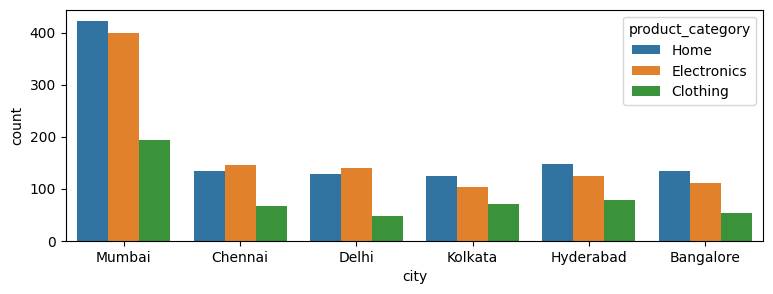

In [35]:
plt.figure(figsize = (9,3))
sns.countplot(x = 'city', data = df, hue = 'product_category')

In [36]:
df['product_category'] = df['product_category'].fillna(df.groupby('city')['product_category'].transform(lambda x: x.mode()[0] if not x.mode().empty else 'unknown'))

In [37]:
df.groupby('loyalty_member')['rating'].mean()

loyalty_member
0    3.030938
1    3.023083
Name: rating, dtype: float64

In [38]:
df['loyalty_member'] = df['loyalty_member'].fillna(-1)

In [39]:
df.dropna(inplace = True)

In [40]:
df['customer_id'] = df['customer_id'].astype(int)

In [41]:
valid_age = (df['age'] >= 18) & (df['age'] <= 80)
valid_purchase = (df['purchase_amount'] >= 0) & (df['purchase_amount'] < df['purchase_amount'].quantile(0.99))
df = df[valid_age & valid_purchase]

In [42]:
df = df.reset_index(drop=True)

In [43]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3187 entries, 0 to 3186
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customer_id       3187 non-null   int64         
 1   age               3187 non-null   int64         
 2   gender            3187 non-null   str           
 3   annual_income     3187 non-null   int64         
 4   purchase_amount   3187 non-null   int64         
 5   purchase_date     3187 non-null   datetime64[us]
 6   city              3187 non-null   str           
 7   product_category  3187 non-null   str           
 8   rating            3187 non-null   float64       
 9   loyalty_member    3187 non-null   object        
dtypes: datetime64[us](1), float64(1), int64(4), object(1), str(3)
memory usage: 249.1+ KB


# Data Analysis

In [44]:
# What is the age distribution of customers?
average = df['age'].mean()
median = df['age'].median()
print("The average age of customers is: ", median)

The average age of customers is:  43.0


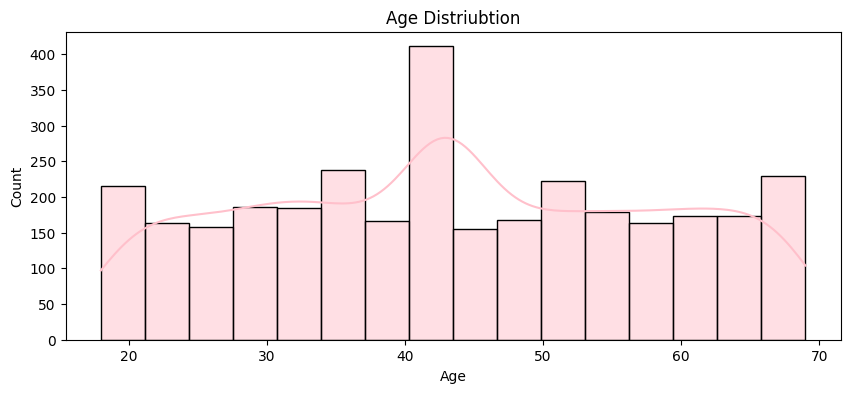

In [45]:
plt.figure(figsize=(10,4))
sns.histplot(df['age'], color='pink', kde=True)
plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Age Distriubtion")
plt.show()


In [46]:
# Do male and female customers spend differently?
df.groupby('gender')['purchase_amount'].mean()

gender
Female    2449.381343
Male      2527.840823
Name: purchase_amount, dtype: float64

In [47]:
df.groupby('gender')['purchase_amount'].sum()

gender
Female    3282171
Male      4668922
Name: purchase_amount, dtype: int64

In [48]:
df.groupby('gender')['purchase_amount'].count()

gender
Female    1340
Male      1847
Name: purchase_amount, dtype: int64

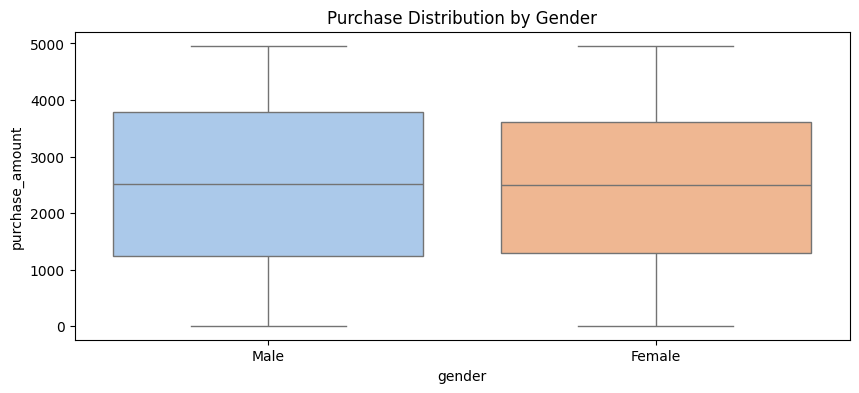

In [49]:
plt.figure(figsize = (10,4))
sns.boxplot(data = df, x = 'gender', y = 'purchase_amount', palette = 'pastel')
plt.title('Purchase Distribution by Gender')
plt.show()

In [50]:
# Which city generates the highest total revenue?
city = df.groupby('city')['purchase_amount'].sum().idxmax()
print("The city with highest purchases: ", city)

The city with highest purchases:  Mumbai


In [51]:
df.groupby('city')['purchase_amount'].sum()

city
Bangalore     908810
Chennai      1007440
Delhi         948380
Hyderabad    1095547
Kolkata       977992
Mumbai       3012924
Name: purchase_amount, dtype: int64

In [52]:
df.groupby('city')['purchase_amount'].mean()

city
Bangalore    2503.608815
Chennai      2457.170732
Delhi        2515.596817
Hyderabad    2461.903371
Kolkata      2709.119114
Mumbai       2447.541836
Name: purchase_amount, dtype: float64

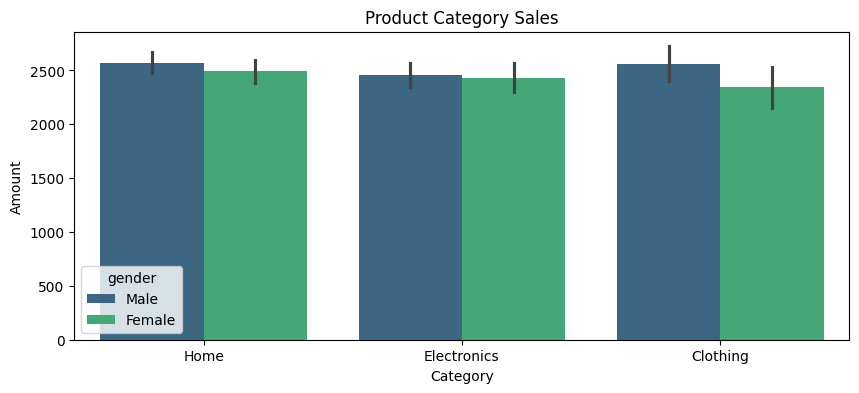

In [53]:
# Which product category performs best?
plt.figure(figsize = (10,4))
sns.barplot(data = df, x = 'product_category', y = 'purchase_amount', palette = 'viridis', hue = 'gender')
plt.title('Product Category Sales')
plt.xlabel('Category')
plt.ylabel('Amount')
plt.show()

In [54]:
df.groupby('product_category')['purchase_amount'].sum()

product_category
Clothing       1228574
Electronics    2793691
Home           3928828
Name: purchase_amount, dtype: int64

In [55]:
df.groupby('product_category')['purchase_amount'].mean()

product_category
Clothing       2467.016064
Electronics    2448.458370
Home           2538.002584
Name: purchase_amount, dtype: float64

In [56]:
df.groupby('product_category')['purchase_amount'].count()

product_category
Clothing        498
Electronics    1141
Home           1548
Name: purchase_amount, dtype: int64

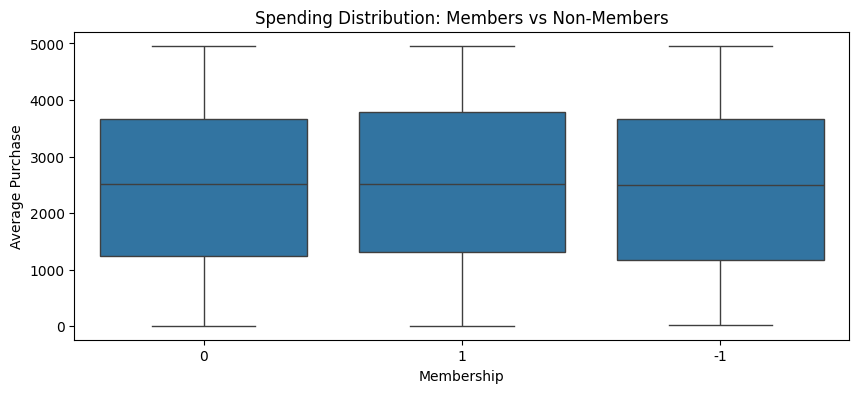

In [57]:
plt.figure(figsize = (10, 4))
sns.boxplot(data = df, x = 'loyalty_member', y = 'purchase_amount')
plt.title('Spending Distribution: Members vs Non-Members')
plt.ylabel('Average Purchase')
plt.xlabel('Membership')
plt.show()

In [58]:
df.groupby('loyalty_member')['purchase_amount'].mean()

loyalty_member
-1    2429.955513
0     2482.202866
1     2532.295387
Name: purchase_amount, dtype: float64

In [59]:
df.groupby('loyalty_member')['purchase_amount'].sum()

loyalty_member
-1    1256287
0     3291401
1     3403405
Name: purchase_amount, dtype: int64

In [60]:
df.groupby('loyalty_member')['purchase_amount'].count()

loyalty_member
-1     517
0     1326
1     1344
Name: purchase_amount, dtype: int64

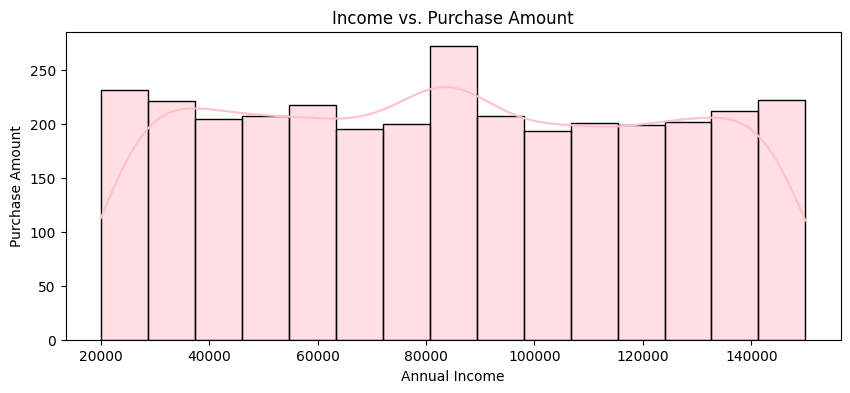

In [61]:
# Does higher income lead to higher spending?
plt.figure(figsize=(10, 4))
sns.histplot(df['annual_income'], kde= True, color = 'pink')

plt.title('Income vs. Purchase Amount')
plt.xlabel('Annual Income')
plt.ylabel('Purchase Amount')

plt.show()

In [62]:
df["annual_income"].corr(df["purchase_amount"])

np.float64(0.0045426045654725685)

In [63]:
# Which age group spends the most money?
bins = [0, 18, 25, 35, 45, 55, 65, 100]
labels = ['<18', '18-25', '26-35', '36-45', '46-55', '56-65', '65+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)


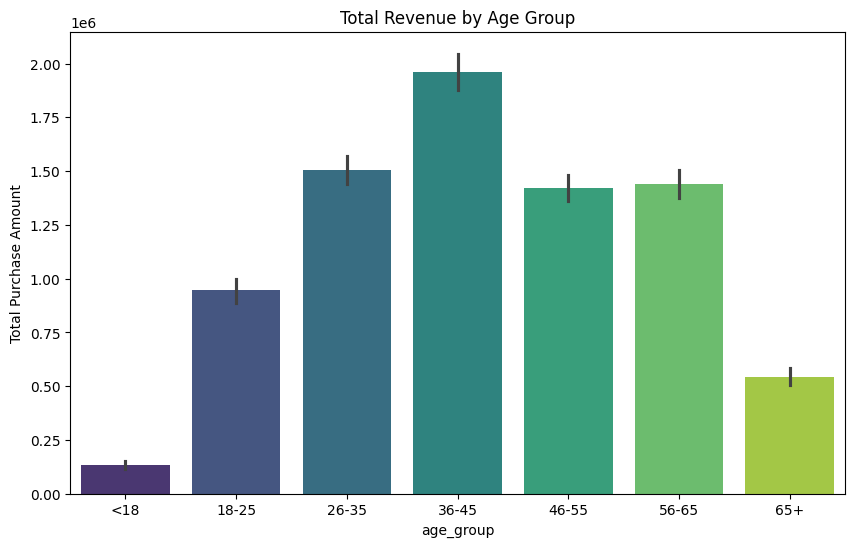

In [64]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='age_group', y='purchase_amount', estimator=sum, palette='viridis')

plt.title('Total Revenue by Age Group')
plt.ylabel('Total Purchase Amount')
plt.show()

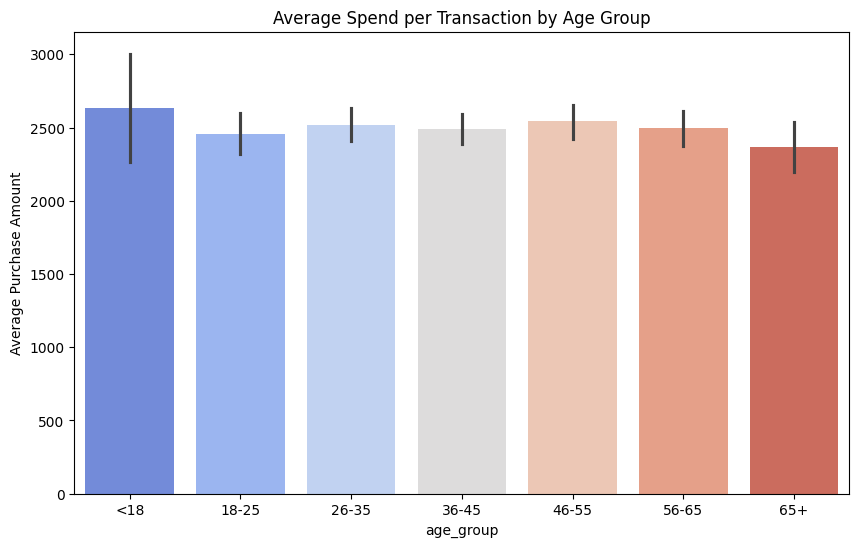

In [65]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='age_group', y='purchase_amount', palette='coolwarm')

plt.title('Average Spend per Transaction by Age Group')
plt.ylabel('Average Purchase Amount')
plt.show()

In [66]:
# Segment customers based on income levels.
min_income = df['annual_income'].min()
max_income = df['annual_income'].max()

bins = [min_income - 1, 40000, 80000, max_income + 1]
labels = ['Low Income', 'Middle Income', 'High Income']

df['income_level'] = pd.cut(df['annual_income'], bins=bins, labels=labels)


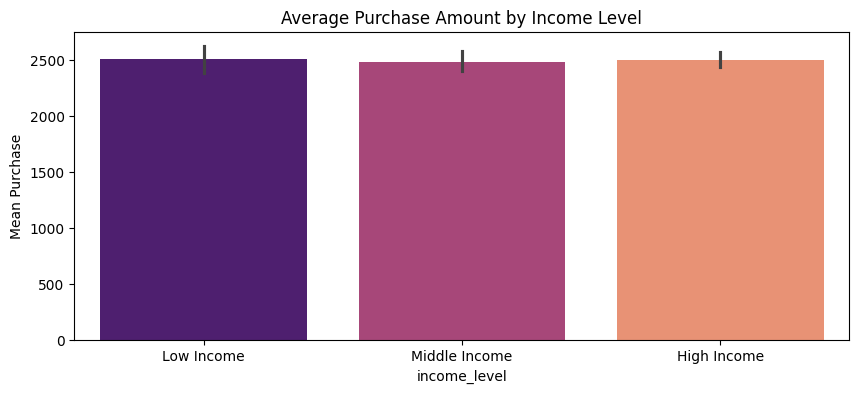

In [67]:
plt.figure(figsize=(10,4))
sns.barplot(data=df, x='income_level', y='purchase_amount', palette='magma')

plt.title('Average Purchase Amount by Income Level')
plt.ylabel('Mean Purchase')
plt.show()

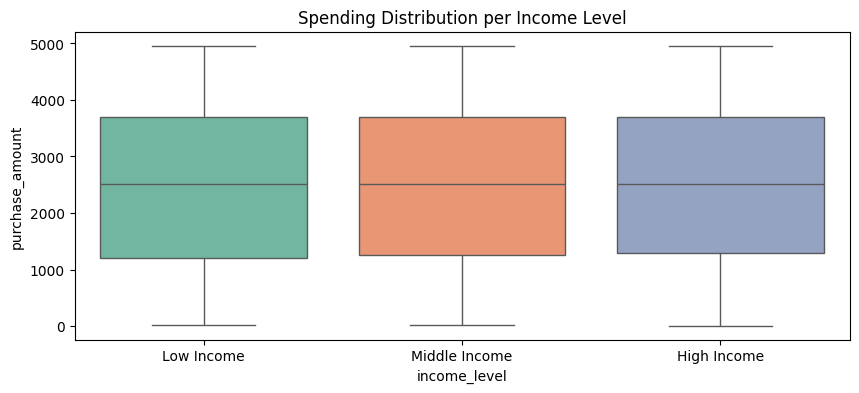

In [68]:
plt.figure(figsize=(10, 4))
sns.boxplot(data=df, x='income_level', y='purchase_amount', palette='Set2')

plt.title('Spending Distribution per Income Level')
plt.show()

In [69]:
# Which city has the highest number of purchases?
print("City With Highest Number of Purchases: ",  df.groupby('city')['purchase_amount'].count().idxmax())
print("Number of Purchases: ", df.groupby('city')['purchase_amount'].count().max())
print("Sum of Purchases: ", df.groupby('city')['purchase_amount'].sum().max())

City With Highest Number of Purchases:  Mumbai
Number of Purchases:  1231
Sum of Purchases:  3012924


In [70]:
# Which cities have the highest-income customers?
df.groupby('city')['annual_income'].mean().idxmax()

'Kolkata'